# GCI 2025 Final Assignment

- Let's begin to code
- I hope I will learn so many thing while doing this assignment.

In [580]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [581]:
# to make sure graphs look okay
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [582]:
## load the dataset
df = pd.read_csv('data.csv')

In [583]:
print("Data Shape:", df.shape)
print("--------------------------------------")
print(df.info())
print("--------------------------------------")
df.head()

Data Shape: (1470, 44)
--------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 44 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   Department                1470 non-null   object
 4   DistanceFromHome          1470 non-null   int64 
 5   Education                 1470 non-null   int64 
 6   EducationField            1470 non-null   object
 7   EmployeeCount             1470 non-null   int64 
 8   EmployeeNumber            1470 non-null   int64 
 9   EnvironmentSatisfaction   1470 non-null   int64 
 10  Gender                    1470 non-null   object
 11  PerformanceIndex          1470 non-null   int64 
 12  JobInvolvement            1470 non-null   int64 
 13  JobLevel        

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,RemoteWork,MonthlyIncome,StressRating,WelfareBenefits,InHouseFacility,ExternalFacility,ExtendedLeave,FlexibleWork,StressSelfReported,Year
0,41,Yes,Travel_Rarely,Sales,1,2,Life Sciences,1,1,2,...,1,5224,4,1,0,0,0,0,1,2023
1,49,No,Travel_Frequently,Research & Development,8,1,Life Sciences,1,2,3,...,3,6863,2,4,1,0,0,1,1,2023
2,37,Yes,Travel_Rarely,Research & Development,2,2,Other,1,4,4,...,2,7612,3,2,1,0,0,0,1,2023
3,33,No,Travel_Frequently,Research & Development,3,4,Life Sciences,1,5,4,...,2,11245,1,4,1,1,1,1,1,2023
4,27,No,Travel_Rarely,Research & Development,2,1,Medical,1,7,1,...,2,3029,3,2,0,0,0,0,3,2023


In [584]:
## convert target 'Attrition' to numbers
# Yes -> 1, No -> 0
df['Attrition'] = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

In [585]:
## find and drop useless columns
# we look for columns that only have 1 unique value (e.g. everyone is 'Over18')
useless_cols = []
for col in df.columns:
    if df[col].nunique() == 1:
        useless_cols.append(col)

print("dropping these useless columns:", useless_cols)    

# Drop them
df.drop(columns=useless_cols, inplace=True)

dropping these useless columns: ['EmployeeCount', 'Over18', 'StandardHours']


In [586]:
## removing 'EmployeeNumber' too, it's just an ID like a roll number, doesn't predict anything
if 'EmployeeNumber' in df.columns:
    df.drop(columns=['EmployeeNumber'], inplace=True)

print("New Data Shape:", df.shape)
df.head()

New Data Shape: (1470, 40)


,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,PerformanceIndex,...,RemoteWork,MonthlyIncome,StressRating,WelfareBenefits,InHouseFacility,ExternalFacility,ExtendedLeave,FlexibleWork,StressSelfReported,Year
0,41,1,Travel_Rarely,Sales,1,2,Life Sciences,2,Female,94,...,1,5224,4,1,0,0,0,0,1,2023
1,49,0,Travel_Frequently,Research & Development,8,1,Life Sciences,3,Male,61,...,3,6863,2,4,1,0,0,1,1,2023
2,37,1,Travel_Rarely,Research & Development,2,2,Other,4,Male,92,...,2,7612,3,2,1,0,0,0,1,2023
3,33,0,Travel_Frequently,Research & Development,3,4,Life Sciences,4,Female,56,...,2,11245,1,4,1,1,1,1,1,2023
4,27,0,Travel_Rarely,Research & Development,2,1,Medical,1,Male,40,...,2,3029,3,2,0,0,0,0,3,2023


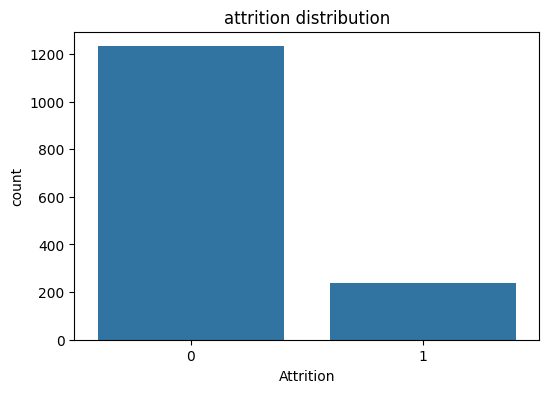

In [587]:
# checking how many people actually left
plt.figure(figsize=(6,4))
sns.countplot(x='Attrition', data=df)
plt.title('attrition distribution')
plt.show()

In [588]:
# finding what features correlate most with attrition
# using numeric_only=True to avoid errors with text columns
correlations = df.corr(numeric_only=True)['Attrition'].sort_values()

In [589]:
print("features that lower attrition (negative correlation):")
print(correlations.head(10))

features that lower attrition (negative correlation):
Incentive              -0.201697
JobLevel               -0.191087
TotalWorkingYears      -0.175436
YearsWithCurrManager   -0.159634
Age                    -0.158683
YearsInCurrentRole     -0.154373
ExtendedLeave          -0.149084
YearsAtCompany         -0.142983
RemoteWork             -0.128057
WelfareBenefits        -0.112692
Name: Attrition, dtype: float64


In [590]:
print("\nfeatures that increase attrition (positive correlation):")
print(correlations.tail(10))


features that increase attrition (positive correlation):
PerformanceRating    -0.029690
PerformanceIndex     -0.014094
MonthlyAchievement    0.000276
Year                  0.011080
OverTime              0.037973
StressSelfReported    0.039347
NumCompaniesWorked    0.058003
DistanceFromHome      0.074684
StressRating          0.184437
Attrition             1.000000
Name: Attrition, dtype: float64


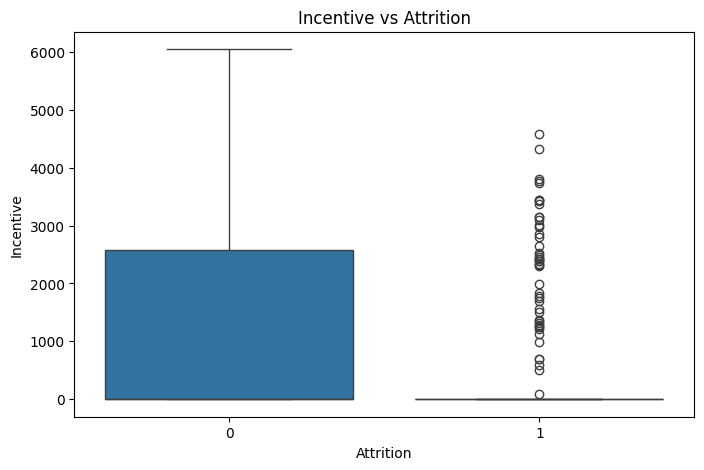

In [591]:
## visualizing the 'incentive' impact
## this is important for our later proposal
plt.figure(figsize=(8, 5))
sns.boxplot(x='Attrition', y='Incentive', data=df)
plt.title('Incentive vs Attrition')
plt.show()

In [592]:
# identifying categorical columns that need conversion
cat_cols = df.select_dtypes(include=['object']).columns
print("categorical columns:", cat_cols)

categorical columns: Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'HowToEmploy'],
      dtype='object')


In [593]:
# using get_dummies to convert text to numbers
# drop_first=True helps reduce extra columns
df_final = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print("shape after encoding:", df_final.shape)

shape after encoding: (1470, 58)


In [594]:
# separating features (X) and target (y)
X = df_final.drop('Attrition', axis=1)
y = df_final['Attrition']

In [595]:
# splitting data: 80% for training, 20% for testing
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("training size:", X_train.shape)
print("testing size:", X_test.shape)

training size: (1176, 57)
testing size: (294, 57)


In [596]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

In [597]:
## setup the model
## we use typical 'student' parameters. n_estimators=100 means it learns 100 times.
model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    random_state=42
)

In [598]:
## train the model (Fit)
print("Training the model...")
model.fit(X_train, y_train)

Training the model...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 197, number of negative: 979
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000292 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1144
[LightGBM] [Info] Number of data points in the train set: 1176, number of used features: 57
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.167517 -> initscore=-1.603328
[LightGBM] [Info] Start training from score -1.603328


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [599]:
## make predictions on the hidden test set
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1] # Probability score for AUC

In [600]:
## check the scores
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

In [601]:
print(f"Model Accuracy: {acc:.4f}")
print(f"Model ROC-AUC: {auc:.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Model Accuracy: 0.8810
Model ROC-AUC: 0.8486

Confusion Matrix:
 [[242  11]
 [ 24  17]]


In [602]:
# getting feature importance from the model
importance = model.feature_importances_
feature_names = X.columns

In [603]:
# creating a dataframe to view it easily
feature_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values(by='importance', ascending=False)

In [604]:
# seeing the top 10 most important features
print("top 10 important features:")
print(feature_imp.head(10))

top 10 important features:
                 feature  importance
23         MonthlyIncome         321
8     MonthlyAchievement         208
10              OverTime         166
0                    Age         157
21             Incentive         152
4       PerformanceIndex         146
1       DistanceFromHome         125
9     NumCompaniesWorked         120
24          StressRating         113
20  YearsWithCurrManager         100


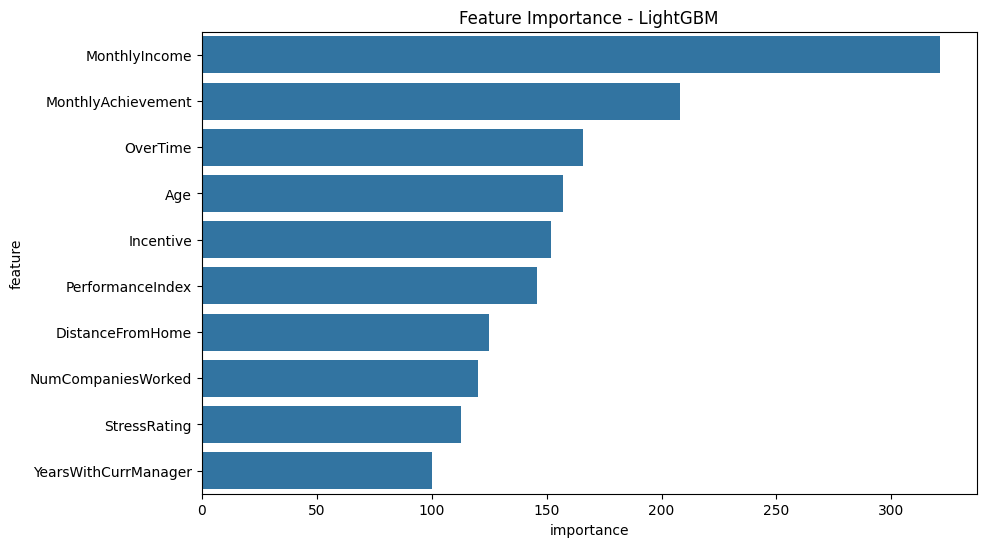

In [605]:
# plotting it nicely
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_imp.head(10))
plt.title('Feature Importance - LightGBM')
plt.show()

In [606]:
## business simulation
cost_of_hiring = 30000 
cost_of_package = 5000 # higher cost because we are giving stock options too

In [607]:
## select high risk employees again
high_risk_indices = y_prob > 0.5
high_risk_employees = X_test[high_risk_indices].copy()

In [608]:
## apply the "premium retention package"
# we max out both incentive and stock options
# this simulates a "counter-offer" when someone tries to resign
if 'Incentive' in high_risk_employees.columns:
    high_risk_employees['Incentive'] = 4 

if 'StockOptionLevel' in high_risk_employees.columns:
    high_risk_employees['StockOptionLevel'] = 3

In [609]:
## predict
new_preds = model.predict(high_risk_employees)

In [610]:
## calculate results
saved_employees = len(high_risk_employees) - sum(new_preds)
retention_rate = saved_employees / len(high_risk_employees) * 100

In [611]:
print(f"employees initially predicted to leave: {len(high_risk_employees)}")
print(f"employees saved with premium package: {saved_employees}")
print(f"retention success rate: {retention_rate:.1f}%")

employees initially predicted to leave: 28
employees saved with premium package: 12
retention success rate: 42.9%


In [612]:
## financial impact
total_savings = saved_employees * cost_of_hiring
total_cost = len(high_risk_employees) * cost_of_package
net_profit = total_savings - total_cost

In [613]:
print("------------------------------------------------")
print(f"projected savings: ${total_savings:,}")
print(f"projected cost: ${total_cost:,}")
print(f"net profit: ${net_profit:,}")
print("------------------------------------------------")

------------------------------------------------
projected savings: $360,000
projected cost: $140,000
net profit: $220,000
------------------------------------------------


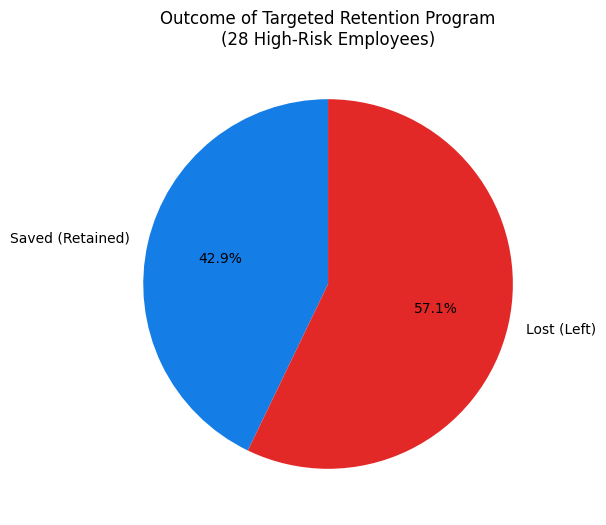

In [ ]:
## pie chart for retention simulation
# numbers from our previous step
labels = ['Saved (Retained)', 'Lost (Left)']
sizes = [12, 16] # 12 saved, 16 still left
colors = ["#147de6", "#e32828"]

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Outcome of Targeted Retention Program\n(28 High-Risk Employees)')

plt.show()